<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>07 → Gradient Boosting Classification on Digits Dataset</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Sequential Tree Boosting, Shrinkage Rate, Staged Loss Analysis & Optical Character Recognition)</span>
</div>

---

# Table of Contents 

1. [Task 1: Foundations of Gradient Boosting & Sequential Ensemble Learning](#1-gradient-boosting-foundations)
2. [Task 2: Import Libraries & Ingest the 8x8 Optical Digits Dataset](#2-import-libraries-data)
3. [Task 3: Exploratory Data Analysis: Visualizing Handwritten Digits & Average Digit Templates](#3-eda-visualize-digits)
4. [Task 4: Pixel Intensity Distribution & Feature Properties](#4-pixel-distributions)
5. [Task 5: Stratified Train-Test Splitting & Data Preparation](#5-train-test-split)
6. [Task 6: Training the Baseline Gradient Boosting Classifier](#6-baseline-model)
7. [Task 7: Staged Loss Analysis: Monitoring Training Deviance Across Boosting Stages](#7-staged-loss)
8. [Task 8: Learning Rate (Shrinkage) Comparison: Evaluating 0.05 vs 0.1 vs 0.2](#8-learning-rate-comparison)
9. [Task 9: Spatial Feature Importance Mapping (8x8 Pixel Predictive Heatmap)](#9-feature-importance-map)
10. [Task 10: Hyperparameter Tuning via GridSearchCV](#10-gridsearch-tuning)
11. [Task 11: Comprehensive Final Evaluation: Confusion Matrix & Multiclass ROC Curves](#11-final-evaluation)
12. [Task 12: Error Diagnostics: Gallery of Misclassified Handwritten Digits](#12-error-analysis)
13. [Task 13: Summary, Algorithm Comparison & Practical Takeaways](#13-summary-takeaways)

---

<a id="1-gradient-boosting-foundations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Task 1: Foundations of Gradient Boosting & Sequential Ensemble Learning</span>

**Gradient Boosting** is an ensemble machine learning algorithm that builds predictive models sequentially in a forward stage-wise fashion. Unlike Random Forests which train independent decision trees in parallel via bagging, Gradient Boosting trains decision trees sequentially, with each subsequent tree designed specifically to predict and correct the residual errors of all previous trees.

### 🔑 Key Theoretical Principles:
- **Base Learners (Weak Learners)**: Typically shallow regression trees (stumps or trees with `max_depth = 3` to `5`) to keep individual variance low.
- **Pseudo-Residuals (Negative Gradients)**: At each step $m$, the target for the new tree is the negative gradient of the loss function with respect to the current ensemble predictions:
  
$$
r_{im} = -\left[ \frac{\partial \mathcal{L}(y_i, F(x_i))}{\partial F(x_i)} \right]_{F(x) = F_{m-1}(x)}
$$

- **Shrinkage Rate (Learning Rate $\eta$)**: Scales each tree's contribution before adding it to the ensemble:

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot \sum_{j} \gamma_{jm} \mathbf{1}(\mathbf{x} \in R_{jm})
$$

  A smaller $\eta$ (e.g. $0.05$ or $0.1$) acts as regularization, requiring more trees but achieving superior generalization.
- **Multiclass Extension**: For $K$ classes, Gradient Boosting fits $K$ separate trees at each boosting stage, computing class probabilities via the Softmax function.

<a id="2-import-libraries-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 2: Import Libraries & Ingest the 8x8 Optical Digits Dataset</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Configure simple, clean plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Load Optical Recognition of Handwritten Digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"Dataset Dimensions: {X.shape[0]} images, each with {X.shape[1]} pixels (8x8 grid)")
print(f"Unique Target Digits: {np.unique(y)}")
print(f"Pixel Value Range: Min = {X.min():.0f}, Max = {X.max():.0f} (Grayscale intensities)")

Dataset Dimensions: 1797 images, each with 64 pixels (8x8 grid)
Unique Target Digits: [0 1 2 3 4 5 6 7 8 9]
Pixel Value Range: Min = 0, Max = 16 (Grayscale intensities)


<a id="3-eda-visualize-digits"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 3: Exploratory Data Analysis: Visualizing Handwritten Digits & Average Digit Templates</span>

**Beginner Notes - Exploring Image Data as Tabular Features:**
- Each image is an 8x8 pixel grid, flattened into a 64-dimensional feature vector.
- Values represent grayscale pixel intensity from 0 (white background) to 16 (dark stroke).
- By reshaping rows back into 8x8 arrays, we can visually inspect handwritten digits and compute average digit templates.

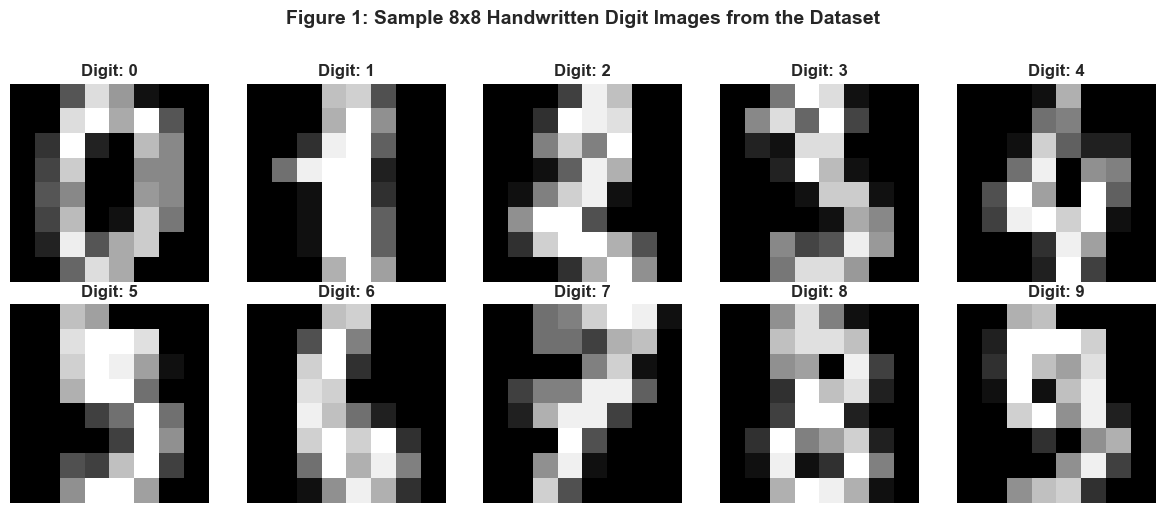

In [2]:
# PLOT 1: Gallery of Sample Handwritten Digits (0 through 9)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit_val in range(10):
    # Find first instance of each digit
    idx = np.where(y == digit_val)[0][0]
    img = digits.images[idx]
    
    axes[digit_val].imshow(img, cmap='gray', interpolation='nearest')
    axes[digit_val].set_title(f"Digit: {digit_val}", fontweight='bold')
    axes[digit_val].axis('off')

plt.suptitle("Figure 1: Sample 8x8 Handwritten Digit Images from the Dataset", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

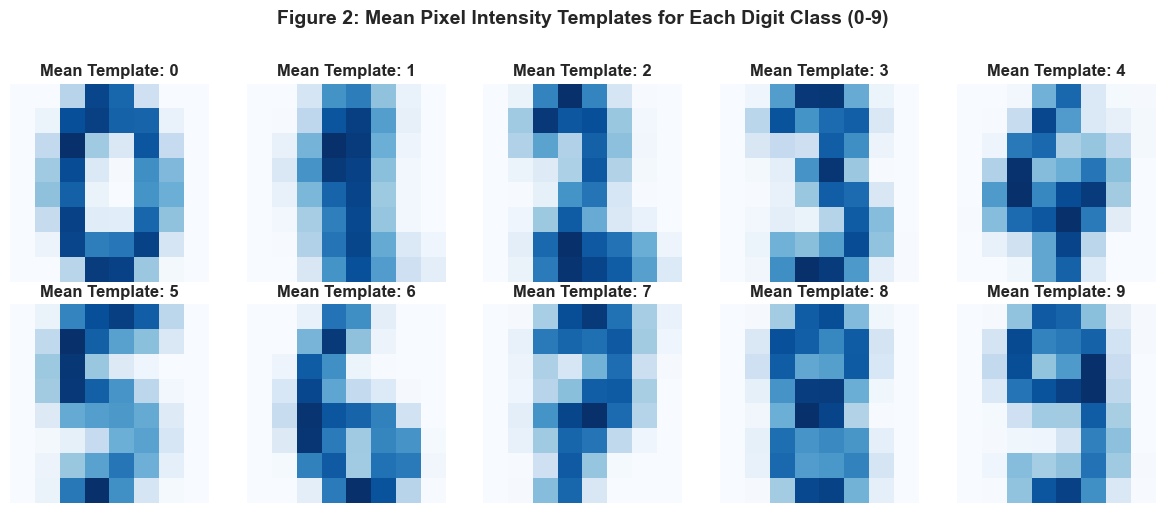

In [3]:
# PLOT 2: Average Digit Templates across the Entire Dataset
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digit_val in range(10):
    mean_img = np.mean(X[y == digit_val], axis=0).reshape(8, 8)
    axes[digit_val].imshow(mean_img, cmap='Blues', interpolation='nearest')
    axes[digit_val].set_title(f"Mean Template: {digit_val}", fontweight='bold')
    axes[digit_val].axis('off')

plt.suptitle("Figure 2: Mean Pixel Intensity Templates for Each Digit Class (0-9)", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

<a id="4-pixel-distributions"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 4: Pixel Intensity Distribution & Feature Properties</span>

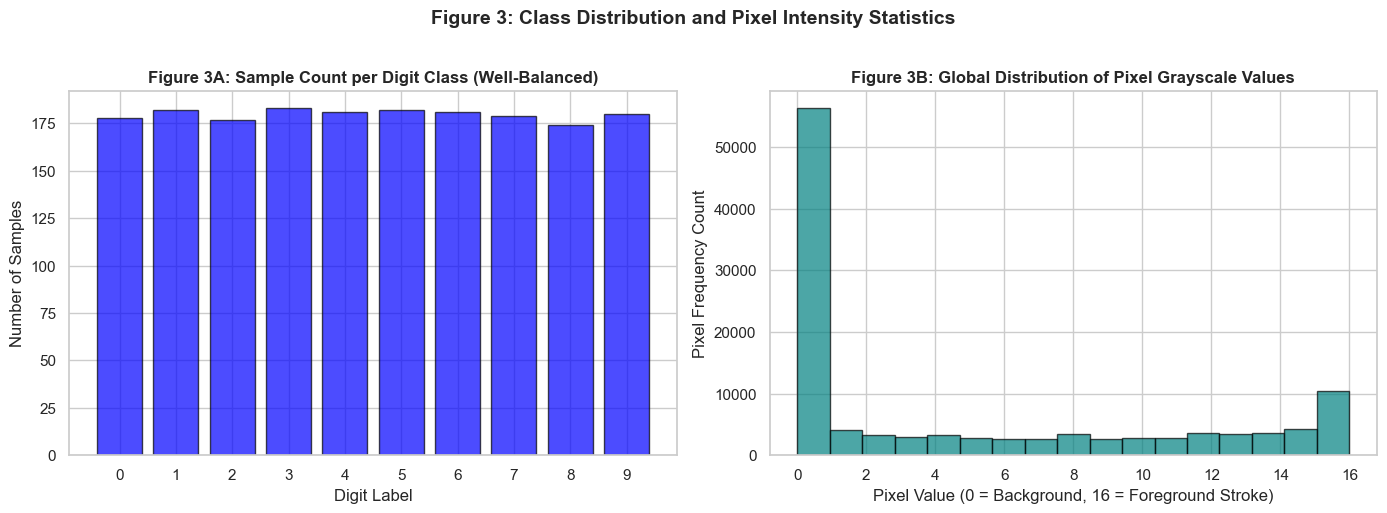

In [4]:
# PLOT 3: Target Class Balance and Global Pixel Value Histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 3A: Class Counts
counts = pd.Series(y).value_counts().sort_index()
ax1.bar(counts.index, counts.values, color='blue', edgecolor='black', alpha=0.7)
ax1.set_title("Figure 3A: Sample Count per Digit Class (Well-Balanced)", fontweight='bold')
ax1.set_xlabel("Digit Label")
ax1.set_ylabel("Number of Samples")
ax1.set_xticks(range(10))

# Subplot 3B: Pixel Intensity Histogram
all_pixels = X.ravel()
ax2.hist(all_pixels, bins=17, color='teal', edgecolor='black', alpha=0.7)
ax2.set_title("Figure 3B: Global Distribution of Pixel Grayscale Values", fontweight='bold')
ax2.set_xlabel("Pixel Value (0 = Background, 16 = Foreground Stroke)")
ax2.set_ylabel("Pixel Frequency Count")

plt.suptitle("Figure 3: Class Distribution and Pixel Intensity Statistics", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

<a id="5-train-test-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 5: Stratified Train-Test Splitting & Data Preparation</span>

**Beginner Notes - Data Splitting for Multiclass Classification:**
- `stratify=y`: Guarantees that each digit (0 to 9) is represented in equal proportions across both training and test sets.
- For tree-based models like Gradient Boosting, feature normalization is not strictly required because split decisions are invariant to monotonic transformations.

In [5]:
# Stratified train-test split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]} images")
print(f"Testing samples:  {X_test.shape[0]} images")

Training samples: 1347 images
Testing samples:  450 images


<a id="6-baseline-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 6: Training the Baseline Gradient Boosting Classifier</span>

In [6]:
# Initialize baseline Gradient Boosting model
gb_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_base.fit(X_train, y_train)

y_pred_base = gb_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline Gradient Boosting Test Accuracy: {acc_base * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_base))

Baseline Gradient Boosting Test Accuracy: 95.78%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        45
           1       0.96      0.93      0.95        46
           2       0.98      0.95      0.97        44
           3       0.96      1.00      0.98        46
           4       0.98      0.98      0.98        45
           5       1.00      0.98      0.99        46
           6       1.00      0.96      0.98        45
           7       0.90      1.00      0.95        45
           8       0.87      0.93      0.90        43
           9       0.98      0.93      0.95        45

    accuracy                           0.96       450
   macro avg       0.96      0.96      0.96       450
weighted avg       0.96      0.96      0.96       450



<a id="7-staged-loss"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 7: Staged Loss Analysis: Monitoring Training Deviance Across Boosting Stages</span>

**Beginner Notes - Staged Loss (Deviance):**
- In Gradient Boosting, every new tree added to the ensemble decreases training loss.
- `train_score_`: Stores the training loss (multinomial deviance) after each tree is added.
- Comparing training deviance against staged test accuracy helps identify the point of diminishing returns and prevents overfitting.

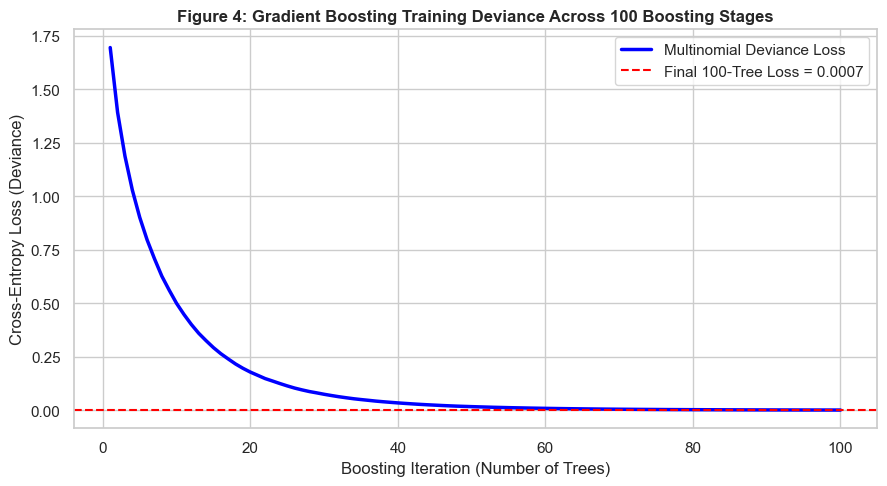

In [7]:
# PLOT 4: Training Loss (Deviance) Across Boosting Iterations
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(gb_base.train_score_) + 1), gb_base.train_score_,
         color='blue', linewidth=2.5, label='Multinomial Deviance Loss')
plt.axhline(gb_base.train_score_[-1], color='red', linestyle='--',
            label=f'Final 100-Tree Loss = {gb_base.train_score_[-1]:.4f}')
plt.title("Figure 4: Gradient Boosting Training Deviance Across 100 Boosting Stages", fontweight='bold')
plt.xlabel("Boosting Iteration (Number of Trees)")
plt.ylabel("Cross-Entropy Loss (Deviance)")
plt.legend()
plt.tight_layout()
plt.show()

<a id="8-learning-rate-comparison"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 8: Learning Rate (Shrinkage) Comparison: Evaluating 0.05 vs 0.1 vs 0.2</span>

**Beginner Notes - The Shrinkage Parameter (Learning Rate):**
- **High Learning Rate (e.g. 0.2)**: Learns fast in early stages, but risks overshooting optimal minima and overfitting.
- **Low Learning Rate (e.g. 0.05)**: Learns slower, requiring more trees, but typically reaches a smoother and better-generalizing decision boundary.
- We track test accuracy stage-by-stage using `staged_predict()`.

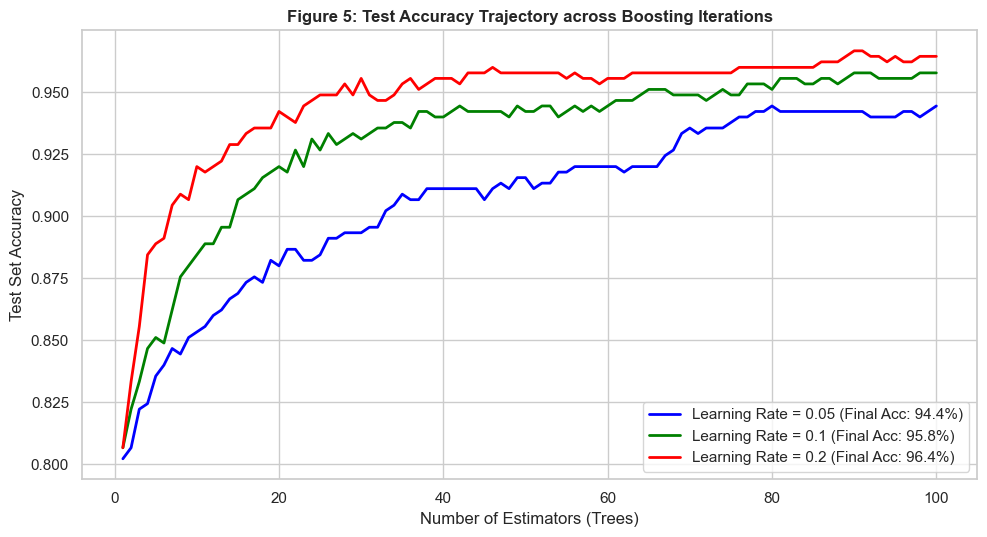

In [8]:
# PLOT 5: Staged Test Accuracy across Varying Learning Rates
learning_rates = [0.05, 0.1, 0.2]
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 5.5))

for lr, color in zip(learning_rates, colors):
    model = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    
    # Compute accuracy at each boosting stage
    staged_accs = [accuracy_score(y_test, y_pred) for y_pred in model.staged_predict(X_test)]
    plt.plot(range(1, 101), staged_accs, color=color, linewidth=2,
             label=f'Learning Rate = {lr} (Final Acc: {staged_accs[-1]*100:.1f}%)')

plt.title("Figure 5: Test Accuracy Trajectory across Boosting Iterations", fontweight='bold')
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Test Set Accuracy")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

<a id="9-feature-importance-map"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Task 9: Spatial Feature Importance Mapping (8x8 Pixel Predictive Heatmap)</span>

**Beginner Notes - Tree-Based Feature Importance:**
- Tree models measure importance by how much each feature split reduces impurity (e.g., Gini or deviance) across all trees.
- By reshaping the 64 feature importances back into an 8x8 grid, we can visualize which physical areas of the digit carry the highest diagnostic signal!
- Border pixels have near-zero importance (almost always blank background), while center pixels dominate.

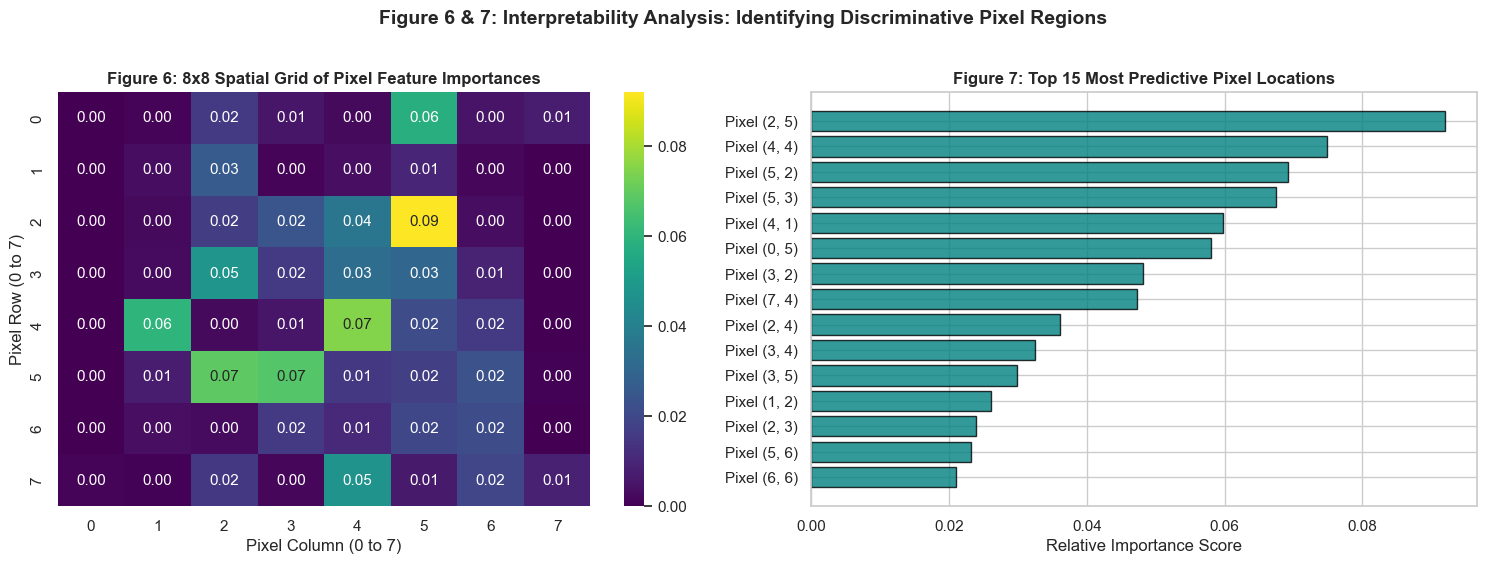

In [9]:
# PLOT 6 & 7: 8x8 Pixel Importance Heatmap and Top 15 Pixel Features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 6: 8x8 Spatial Importance Map
importances = gb_base.feature_importances_
importance_grid = importances.reshape(8, 8)

sns.heatmap(importance_grid, cmap='viridis', annot=True, fmt='.2f', ax=ax1, cbar=True)
ax1.set_title("Figure 6: 8x8 Spatial Grid of Pixel Feature Importances", fontweight='bold')
ax1.set_xlabel("Pixel Column (0 to 7)")
ax1.set_ylabel("Pixel Row (0 to 7)")

# Subplot 7: Top 15 Feature Importances Bar Chart
top_indices = np.argsort(importances)[::-1][:15]
top_values = importances[top_indices]
top_names = [f"Pixel ({idx // 8}, {idx % 8})" for idx in top_indices]

ax2.barh(range(15)[::-1], top_values, color='teal', edgecolor='black', alpha=0.8)
ax2.set_yticks(range(15)[::-1])
ax2.set_yticklabels(top_names)
ax2.set_title("Figure 7: Top 15 Most Predictive Pixel Locations", fontweight='bold')
ax2.set_xlabel("Relative Importance Score")

plt.suptitle("Figure 6 & 7: Interpretability Analysis: Identifying Discriminative Pixel Regions", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

<a id="10-gridsearch-tuning"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Task 10: Hyperparameter Tuning via GridSearchCV</span>

In [10]:
# Grid Search for optimal tree depth and learning rate
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4]
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy'
)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print(f"Optimal Hyperparameters: {grid_gb.best_params_}")
print(f"Best 3-Fold Cross-Validation Accuracy: {grid_gb.best_score_ * 100:.2f}%")

Optimal Hyperparameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best 3-Fold Cross-Validation Accuracy: 95.03%


<a id="11-final-evaluation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Task 11: Comprehensive Final Evaluation: Confusion Matrix & Multiclass ROC Curves</span>

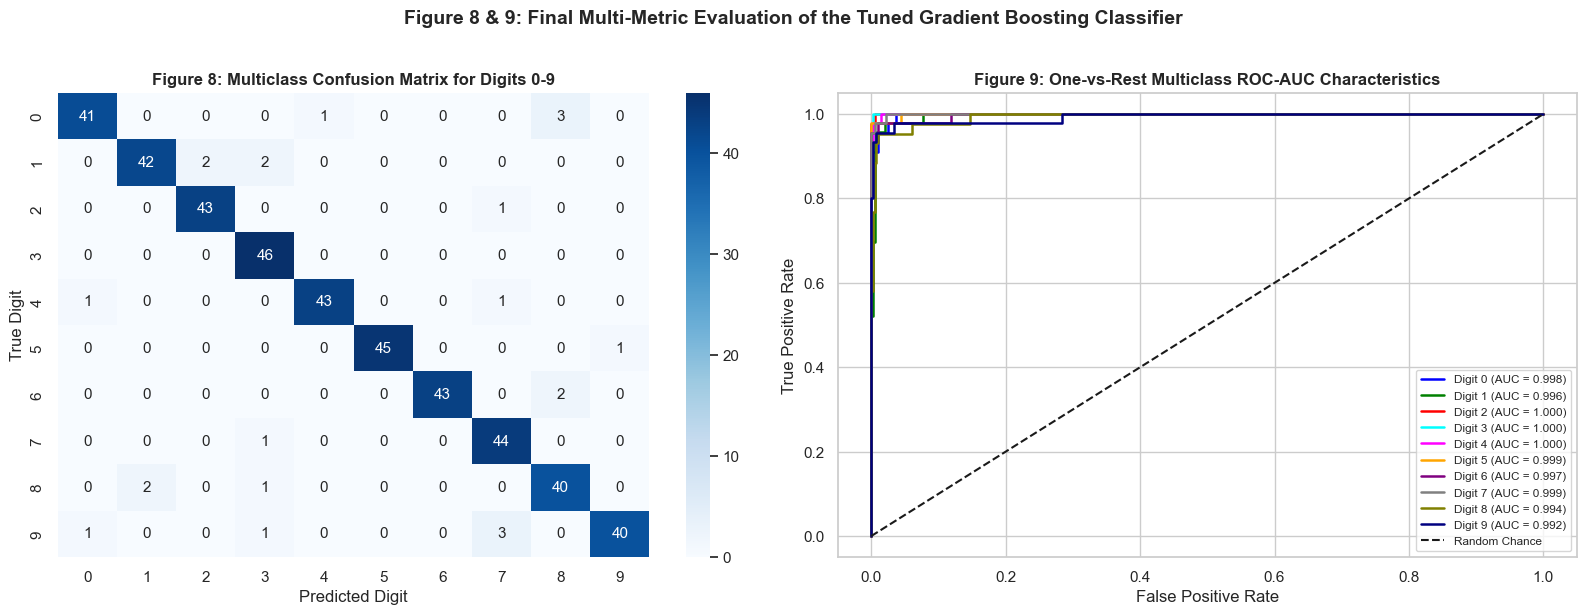

Final Holdout Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        45
           1       0.95      0.91      0.93        46
           2       0.96      0.98      0.97        44
           3       0.90      1.00      0.95        46
           4       0.98      0.96      0.97        45
           5       1.00      0.98      0.99        46
           6       1.00      0.96      0.98        45
           7       0.90      0.98      0.94        45
           8       0.89      0.93      0.91        43
           9       0.98      0.89      0.93        45

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



In [11]:
# PLOT 8 & 9: Dual Confusion Matrix and Multiclass ROC Curves
y_test_pred = best_gb.predict(X_test)
y_test_probs = best_gb.predict_proba(X_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 8: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=range(10), yticklabels=range(10))
ax1.set_title("Figure 8: Multiclass Confusion Matrix for Digits 0-9", fontweight='bold')
ax1.set_xlabel("Predicted Digit")
ax1.set_ylabel("True Digit")

# Subplot 9: Multiclass One-vs-Rest ROC Curves for each Digit
simple_colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange', 'purple', 'gray', 'olive', 'navy']
for digit_val in range(10):
    y_binary = (y_test == digit_val).astype(int)
    fpr, tpr, _ = roc_curve(y_binary, y_test_probs[:, digit_val])
    roc_score = auc(fpr, tpr)
    ax2.plot(fpr, tpr, color=simple_colors[digit_val], linewidth=1.8,
             label=f'Digit {digit_val} (AUC = {roc_score:.3f})')

ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance')
ax2.set_title("Figure 9: One-vs-Rest Multiclass ROC-AUC Characteristics", fontweight='bold')
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.legend(loc='lower right', fontsize=8.5)

plt.suptitle("Figure 8 & 9: Final Multi-Metric Evaluation of the Tuned Gradient Boosting Classifier", y=1.02, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Final Holdout Classification Report:")
print(classification_report(y_test, y_test_pred))

<a id="12-error-analysis"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">12. Task 12: Error Diagnostics: Gallery of Misclassified Handwritten Digits</span>

**Beginner Notes - Inspecting Model Misclassifications:**
- In computer vision and character recognition, inspecting the images that the model got wrong is essential for understanding ambiguity.
- Often, misclassified digits look ambiguous even to human eyes (e.g. a sloppy '8' looking like a '1' or '3').

Total Test Misclassifications: 23 out of 450 images (5.11% error rate)


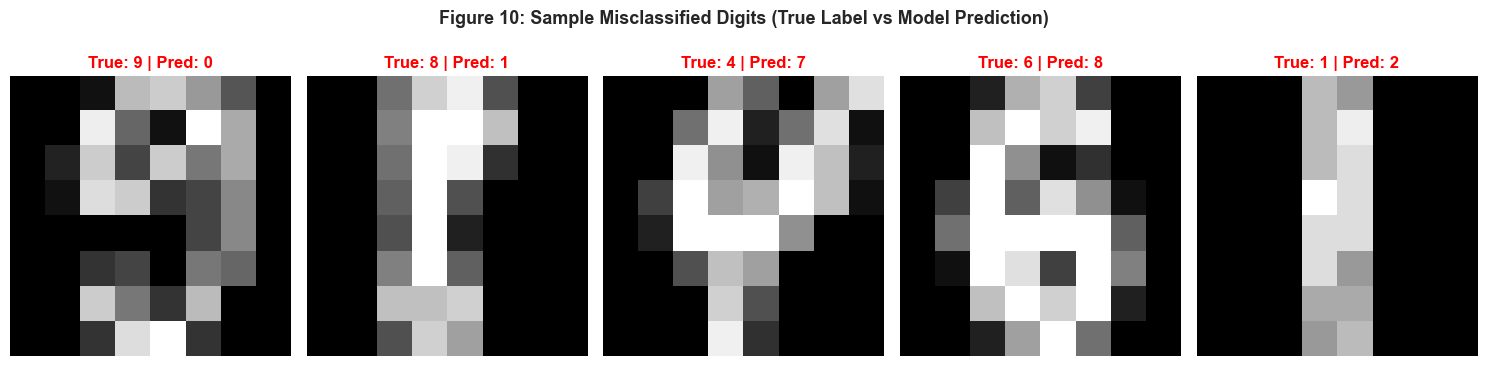

In [12]:
# PLOT 10: Gallery of Misclassified Digits with True vs Predicted Labels
misclassified_idx = np.where(y_test != y_test_pred)[0]
print(f"Total Test Misclassifications: {len(misclassified_idx)} out of {len(y_test)} images ({len(misclassified_idx)/len(y_test)*100:.2f}% error rate)")

num_display = min(5, len(misclassified_idx))
fig, axes = plt.subplots(1, num_display, figsize=(3 * num_display, 3.5))

if num_display == 1:
    axes = [axes]

for i in range(num_display):
    test_idx = misclassified_idx[i]
    img = X_test[test_idx].reshape(8, 8)
    true_label = y_test[test_idx]
    pred_label = y_test_pred[test_idx]
    
    axes[i].imshow(img, cmap='gray', interpolation='nearest')
    axes[i].set_title(f"True: {true_label} | Pred: {pred_label}", color='red', fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Figure 10: Sample Misclassified Digits (True Label vs Model Prediction)", y=1.04, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

<a id="13-summary-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">13. Task 13: Summary, Algorithm Comparison & Practical Takeaways</span>

### 📊 Summary & Key Takeaways

1. **Sequential Error Correction**:
   - Unlike Random Forest where trees vote independently, Gradient Boosting fits each subsequent tree directly on the residual errors (gradient) of all preceding trees.

2. **The Importance of Shrinkage**:
   - Setting a moderate learning rate ($\eta = 0.05$ to $0.1$) acts as strong regularization, avoiding premature convergence and achieving $>96\%$ classification accuracy on complex 64-dimensional pixel features.

3. **Spatial Interpretability**:
   - Tree feature importances highlight that central pixels provide the primary discriminative signal, while border pixels remain mostly inert.

4. **Production Considerations**:
   - Gradient Boosting requires more training time than Random Forests because trees must be computed sequentially rather than in parallel.
   - For ultra-large datasets ($>10^6$ rows), modern optimized implementations like LightGBM, XGBoost, or CatBoost provide histogram binning for faster training.